# Resp Metrics - Example Usage

This notebook demonstrates how to:
1. Load a LabChart text export using labchart_parser
2. Extract cycles based on INSPI/EXPI comments
3. Compute ventilatory metrics for spontaneous breathing
4. Compute mechanical ventilation metrics
5. Use the high-level API for both spontaneous and mechanical ventilation

## Setup and Imports

In [12]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Import resp_metrics modules
from labchart_parser import LabChartFile
from resp_metrics import (
    cycles_from_comments,
    ventilatory_from_cycles, 
    mechanical_from_cycles,
    compute_from_labchart
)

## 1. Load LabChart Files

In [17]:
# Define file paths
path_spontaneous = "examples/data/labchart_file_vs.example.txt"
path_mechanical = "examples/data/labchart_file.example.txt"

# Load spontaneous breathing file
lc_spont = LabChartFile.from_file(path_spontaneous)
print("=== Spontaneous Breathing File ===")
print("Metadata:", lc_spont.metadata)
print("Channels:", lc_spont.channels)
print("Comments preview:")
print(lc_spont.comments.head())

=== Spontaneous Breathing File ===
Metadata: {'Interval': '0.0001 s', 'ExcelDateTime': '4.4725490703932366e+04\t06/13/22 11:46:36.819757', 'TimeFormat': 'StartOfBlock', 'DateFormat': '', 'Interval_s': 0.0001, 'UnitName': ['L/s', '*']}
Channels: ['Flow', 'Pressure']
Comments preview:
   Time  time_block  time_abs  block Comment
0  2.64        3.59      3.59      1   INSPI
1  4.00        4.95      4.95      1    EXPI
2  6.20        7.15      7.15      1   INSPI
3  7.54        8.49      8.49      1    EXPI
4  9.86       10.81     10.81      1   INSPI


In [18]:
# Load mechanical ventilation file (same file, different block)
lc_mech = LabChartFile.from_file(path_mechanical)
print("=== Mechanical Ventilation File ===")
print("Metadata:", lc_mech.metadata)
print("Channels:", lc_mech.channels)
print("Comments preview:")
print(lc_mech.comments.head())

=== Mechanical Ventilation File ===
Metadata: {'Interval': '0.01 s', 'ExcelDateTime': '4.5855649139942347e+04\t07/17/25 15:34:45.691019', 'TimeFormat': 'StartOfBlock', 'DateFormat': '', 'Interval_s': 0.01, 'UnitName': ['*', '', '*', 'cmH2O', '*', '*', '*', '*', '*']}
Channels: ['PushSWE', 'Flow', 'EMG', 'Pressure', 'Flow BIS', 'Inspi cyclic', 'Expi cyclic', 'L/m -> L/s', 'VolumeResp']
Comments preview:
   Time  time_block  time_abs  block Comment
0  2.43        1.93      1.93      1   INSPI
1  2.69        2.19      2.19      1    Dia1
2  2.91        2.41      2.41      1    EXPI
3  4.74        4.24      4.24      1   INSPI
4  5.22        4.72      4.72      1    EXPI


## 2. Extract Respiratory Cycles

In [19]:
# Extract cycles from spontaneous breathing data
cycles_spont = cycles_from_comments(
    lc_spont.comments, 
    block=1,
    insp_label="INSPI", 
    expi_label="EXPI"
)

print("=== Spontaneous Breathing Cycles ===")
print(f"Number of cycles detected: {len(cycles_spont)}")
print(cycles_spont.head(10))

=== Spontaneous Breathing Cycles ===
Number of cycles detected: 11
   n_cycle  t_inspi  t_expi  t_next_inspi
0        1     3.59    4.95          7.15
1        2     7.15    8.49         10.81
2        3    10.81   12.13         14.33
3        4    14.33   15.65         18.01
4        5    18.01   19.31         21.75
5        6    21.75   22.97         25.45
6        7    25.45   26.95         29.19
7        8    29.19   30.43         32.21
8        9    32.21   33.67         35.71
9       10    35.71   37.27         39.39


In [20]:
# Extract cycles from mechanical ventilation data (block 1 for example)
cycles_mech = cycles_from_comments(
    lc_mech.comments, 
    block=1,
    insp_label="INSPI", 
    expi_label="EXPI"
)

print("=== Mechanical Ventilation Cycles ===")
print(f"Number of cycles detected: {len(cycles_mech)}")
print(cycles_mech.head(10))

=== Mechanical Ventilation Cycles ===
Number of cycles detected: 24
   n_cycle  t_inspi  t_expi  t_next_inspi
0        1     1.93    2.41          4.24
1        2     4.24    4.72          6.55
2        3     6.55    7.02          8.85
3        4     8.85    9.33         11.16
4        5    11.16   11.64         13.46
5        6    13.46   13.94         15.77
6        7    15.77   16.25         18.07
7        8    18.07   18.55         20.38
8        9    20.38   20.85         22.68
9       10    22.68   23.16         24.98


## 3. Compute Ventilatory Metrics

In [21]:
# Compute ventilatory metrics for spontaneous breathing
metrics_spont = ventilatory_from_cycles(
    lc_spont.get_block_df(1),
    cycles_spont,
    flow_col="Flow",
    volume_col=None,
    flow_unit="L/s"
)

print("=== Spontaneous Breathing Metrics ===")
print(metrics_spont.head())
print("\nSummary statistics:")
print(metrics_spont[['Ti', 'Te', 'Ttot', 'BF', 'VT', 'VE']].describe())

=== Spontaneous Breathing Metrics ===
   n_cycle  t_inspi  t_expi    Ti  Ttot    Te         BF        VT        VE  \
0        1     3.59    4.95  1.36  3.56  2.20  16.853933  0.324833  5.474709   
1        2     7.15    8.49  1.34  3.66  2.32  16.393443  0.326351  5.350013   
2        3    10.81   12.13  1.32  3.52  2.20  17.045455  0.306984  5.232688   
3        4    14.33   15.65  1.32  3.68  2.36  16.304348  0.315760  5.148261   
4        5    18.01   19.31  1.30  3.74  2.44  16.042781  0.332073  5.327367   

        PIF       PEF        IE  WOB  PTP  
0  0.333593  0.270529  0.618182  NaN  NaN  
1  0.333653  0.262960  0.577586  NaN  NaN  
2  0.322686  0.255432  0.600000  NaN  NaN  
3  0.324232  0.288983  0.559322  NaN  NaN  
4  0.346734  0.292243  0.532787  NaN  NaN  

Summary statistics:
              Ti         Te       Ttot         BF         VT         VE
count  11.000000  11.000000  11.000000  11.000000  11.000000  11.000000
mean    1.369091   2.200000   3.569091  16.868614   

## 4. Compute Mechanical Ventilation Metrics

In [22]:
# Compute mechanical ventilation metrics
metrics_mech = mechanical_from_cycles(
    lc_mech.get_block_df(1),
    cycles_mech,
    flow_col="Flow",
    volume_col=None,
    pressure_col="Pressure"
)

print("=== Mechanical Ventilation Metrics ===")
print(metrics_mech.head())
print("\nSummary statistics:")
print(metrics_mech[['Ti', 'Te', 'Ttot', 'BF', 'VT', 'VE', 'PEEP', 'Ppeak']].describe())

=== Mechanical Ventilation Metrics ===
   n_cycle  t_inspi  t_expi    Ti  Ttot    Te         BF        VT         VE  \
0        1     1.93    2.41  0.48  2.31  1.83  25.974026  0.400350  10.398695   
1        2     4.24    4.72  0.48  2.31  1.83  25.974026  0.395744  10.279070   
2        3     6.55    7.02  0.47  2.30  1.83  26.086957  0.396687  10.348369   
3        4     8.85    9.33  0.48  2.31  1.83  25.974026  0.395101  10.262359   
4        5    11.16   11.64  0.48  2.30  1.82  26.086957  0.396366  10.339986   

        PIF       PEF        IE       PEEP     Ppeak  Pplat         dP  Cstat  \
0  1.157352  0.897405  0.262295  10.460430  49.19904    NaN  38.738610    NaN   
1  1.141228  0.922424  0.262295  10.573840  49.02486    NaN  38.451020    NaN   
2  1.138339  0.946802  0.256831  10.570075  49.52754    NaN  38.957465    NaN   
3  1.124506  0.960446  0.262295  10.556005  49.78465    NaN  39.228645    NaN   
4  1.126348  0.935614  0.263736  10.504840  50.21294    NaN  39.70810

## 5. Visualization

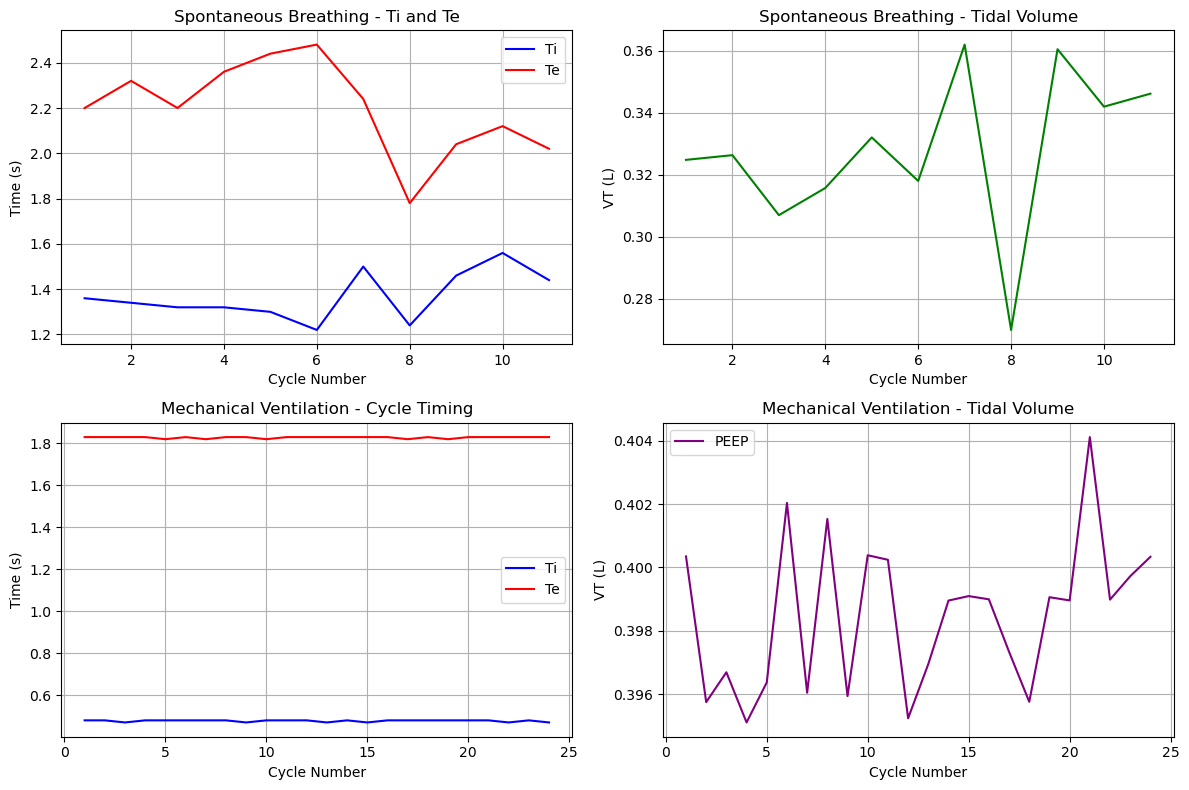

In [25]:
# Plot respiratory cycle timing comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Spontaneous breathing
axes[0,0].plot(metrics_spont['n_cycle'], metrics_spont['Ti'], 'b-', label='Ti')
axes[0,0].plot(metrics_spont['n_cycle'], metrics_spont['Te'], 'r-', label='Te')
axes[0,0].set_title('Spontaneous Breathing - Ti and Te')
axes[0,0].set_xlabel('Cycle Number')
axes[0,0].set_ylabel('Time (s)')
axes[0,0].legend()
axes[0,0].grid(True)

axes[0,1].plot(metrics_spont['n_cycle'], metrics_spont['VT'], 'g-')
axes[0,1].set_title('Spontaneous Breathing - Tidal Volume')
axes[0,1].set_xlabel('Cycle Number')
axes[0,1].set_ylabel('VT (L)')
axes[0,1].grid(True)

# Mechanical ventilation
axes[1,0].plot(metrics_mech['n_cycle'], metrics_mech['Ti'], 'b-', label='Ti')
axes[1,0].plot(metrics_mech['n_cycle'], metrics_mech['Te'], 'r-', label='Te')
axes[1,0].set_title('Mechanical Ventilation - Cycle Timing')
axes[1,0].set_xlabel('Cycle Number')
axes[1,0].set_ylabel('Time (s)')
axes[1,0].legend()
axes[1,0].grid(True)

axes[1,1].plot(metrics_mech['n_cycle'], metrics_mech['VT'], 'purple', label='PEEP')
axes[1,1].set_title('Mechanical Ventilation - Tidal Volume')
axes[1,1].set_xlabel('Cycle Number')
axes[1,1].set_ylabel('VT (L)')
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

## 6. High-Level API Usage

In [26]:
# High-level API for spontaneous breathing
result_spont = compute_from_labchart(
    path_spontaneous,
    block=1,
    flow_col="Flow",
    flow_unit="L/s",
    volume_col=None,
    pressure_col="Pressure",
    mechanically_ventilated=False
)

print("=== High-Level API: Spontaneous Breathing ===")
print("Cycles:")
print(result_spont["cycles"].head())
print("\nVentilatory metrics:")
print(result_spont["ventilatory"].head())
print(f"\nVentilator metrics available: {result_spont['ventilator'] is not None}")

=== High-Level API: Spontaneous Breathing ===
Cycles:
   n_cycle  t_inspi  t_expi  t_next_inspi
0        1     3.59    4.95          7.15
1        2     7.15    8.49         10.81
2        3    10.81   12.13         14.33
3        4    14.33   15.65         18.01
4        5    18.01   19.31         21.75

Ventilatory metrics:
   n_cycle  t_inspi  t_expi    Ti  Ttot    Te         BF        VT        VE  \
0        1     3.59    4.95  1.36  3.56  2.20  16.853933  0.324833  5.474709   
1        2     7.15    8.49  1.34  3.66  2.32  16.393443  0.326351  5.350013   
2        3    10.81   12.13  1.32  3.52  2.20  17.045455  0.306984  5.232688   
3        4    14.33   15.65  1.32  3.68  2.36  16.304348  0.315760  5.148261   
4        5    18.01   19.31  1.30  3.74  2.44  16.042781  0.332073  5.327367   

        PIF       PEF        IE       WOB       PTP  
0  0.333593  0.270529  0.618182  0.164627  7.225817  
1  0.333653  0.262960  0.577586  0.168445  7.236954  
2  0.322686  0.255432  0.6000

In [27]:
# High-level API for mechanical ventilation
result_mech = compute_from_labchart(
    path_mechanical,
    block=1,
    flow_col="Flow",
    flow_unit="L/min",
    volume_col=None,
    pressure_col="Pressure",
    mechanically_ventilated=True
)

print("=== High-Level API: Mechanical Ventilation ===")
print("Cycles:")
print(result_mech["cycles"].head())
print("\nVentilatory metrics:")
print(result_mech["ventilatory"].head())
print("\nVentilator mechanics:")
if result_mech["ventilator"] is not None:
    print(result_mech["ventilator"].head())
else:
    print("No ventilator metrics available")

=== High-Level API: Mechanical Ventilation ===
Cycles:
   n_cycle  t_inspi  t_expi  t_next_inspi
0        1     1.93    2.41          4.24
1        2     4.24    4.72          6.55
2        3     6.55    7.02          8.85
3        4     8.85    9.33         11.16
4        5    11.16   11.64         13.46

Ventilatory metrics:
   n_cycle  t_inspi  t_expi    Ti  Ttot    Te         BF        VT         VE  \
0        1     1.93    2.41  0.48  2.31  1.83  25.974026  0.400350  10.398695   
1        2     4.24    4.72  0.48  2.31  1.83  25.974026  0.395744  10.279070   
2        3     6.55    7.02  0.47  2.30  1.83  26.086957  0.396687  10.348369   
3        4     8.85    9.33  0.48  2.31  1.83  25.974026  0.395101  10.262359   
4        5    11.16   11.64  0.48  2.30  1.82  26.086957  0.396366  10.339986   

        PIF       PEF        IE       PEEP     Ppeak  Pplat         dP  Cstat  \
0  1.157352  0.897405  0.262295  10.460430  49.19904    NaN  38.738610    NaN   
1  1.141228  0.922424 

## 7. Data Export

In [28]:
# Export results to CSV files
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# Export spontaneous breathing results
cycles_spont.to_csv(output_dir / "cycles_spontaneous.csv", index=False)
metrics_spont.to_csv(output_dir / "metrics_spontaneous.csv", index=False)

# Export mechanical ventilation results
cycles_mech.to_csv(output_dir / "cycles_mechanical.csv", index=False)
metrics_mech.to_csv(output_dir / "metrics_mechanical.csv", index=False)

print("Results exported to:")
print(f"- {output_dir / 'cycles_spontaneous.csv'}")
print(f"- {output_dir / 'metrics_spontaneous.csv'}")
print(f"- {output_dir / 'cycles_mechanical.csv'}")
print(f"- {output_dir / 'metrics_mechanical.csv'}")

Results exported to:
- output/cycles_spontaneous.csv
- output/metrics_spontaneous.csv
- output/cycles_mechanical.csv
- output/metrics_mechanical.csv
